# 09_聚类算法-Mini-Batch K-means

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/lenna.jpg`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文大家来聊聊聚类算法中，很重要的一个算法模型：Mini-Batch K-means。

首先，简单回顾什么是聚类算法？

聚类算法就是把一堆数据分成几组（叫“簇”），每组里的数据要尽量相似，而不同组的数据要尽量不同。比如，你有一堆水果，根据颜色和大小分成“苹果”、“香蕉”和“橘子”三类，这就是一个聚类过程。

## Mini-Batch K-means 是什么？

先来看看，K-means 的核心思想：

- 随机选出 $K$个点，作为每个簇的“中心”（叫质心）。
- 把每个数据点分配到离自己最近的那个质心所在的簇。
- 更新每个簇的质心（重新计算每个簇所有点的平均值）。
- 不断重复“分配点”和“更新质心”这两个步骤，直到质心不再变化。

**Mini-Batch K-means 是什么？**

Mini-Batch K-means 是 K-means 的“加速版”，因为普通 K-means 每次都会用全部数据点来更新质心，而如果数据量很大，这样会很慢。所以，Mini-Batch K-means 每次只用一小部分数据（叫一个 mini-batch）来更新质心，速度更快。

### 一个简单案例：用 Mini-Batch K-means 给朋友分组

你有 10 个朋友，想根据他们的兴趣爱好（唱歌、跳舞、画画）分成两组。

**数据：**

朋友们兴趣爱好的评分如下（越高越喜欢，取值 0 到 10）：

| 朋友 | 唱歌评分 | 跳舞评分 | 画画评分 |
|-|-|-|-|
| A | 8 | 2 | 1 |
| B | 7 | 3 | 2 |
| C | 1 | 8 | 2 |
| D | 2 | 7 | 3 |
| E | 2 | 1 | 9 |
| F | 3 | 2 | 8 |
| G | 8 | 1 | 2 |
| H | 7 | 2 | 1 |
| I | 1 | 9 | 2 |
| J | 3 | 8 | 2 |

**步骤：**

**1. 初始化质心**：假设随机选两个朋友 A 和 C 作为初始质心。

- 质心 1（A）：(8, 2, 1)
- 质心 2（C）：(1, 8, 2)

**2. 选取一个 mini-batch**：假设 mini-batch 包括 {B, D, F} 三个人。

**3. 计算离质心的距离**：

距离公式：  
$\text{距离} = \sqrt{(x_1-y_1)^2 + (x_2-y_2)^2 + (x_3-y_3)^2}$  
对每个人计算离两个质心的距离：

- B 到质心 1 的距离：$\sqrt{(7-8)^2 + (3-2)^2 + (2-1)^2} = \sqrt{1+1+1} = 1.73$
- B 到质心 2 的距离：$\sqrt{(7-1)^2 + (3-8)^2 + (2-2)^2} = \sqrt{36+25+0} = 7.81$
- D 到质心 1 的距离：$\sqrt{(2-8)^2 + (7-2)^2 + (3-1)^2} = \sqrt{36+25+4} = 8.06$
- D 到质心 2 的距离：$\sqrt{(2-1)^2 + (7-8)^2 + (3-2)^2} = \sqrt{1+1+1} = 1.73$
- F 到质心 1 的距离：$\sqrt{(3-8)^2 + (2-2)^2 + (8-1)^2} = \sqrt{25+0+49} = 8.60$
- F 到质心 2 的距离：$\sqrt{(3-1)^2 + (2-8)^2 + (8-2)^2} = \sqrt{4+36+36} = 9.22$

**4. 分配簇**：

- B 更靠近质心 1，分到簇 1。
- D 更靠近质心 2，分到簇 2。
- F 更靠近质心 1，分到簇 1。

**5. 更新质心**：

- 簇 1（B, F）：质心 = 平均值 = $((7+3)/2, (3+2)/2, (2+8)/2) = (5, 2.5, 5)$。
- 簇 2（D）：质心 = D 的坐标 = (2, 7, 3)。

**6. 重复迭代**：不断从剩余数据中取 mini-batch（比如 {E, G, H}），重复上述步骤，直到质心稳定不再变化。

总之，每次迭代只用一小部分数据（mini-batch）更新质心，而不是用全部数据。这样处理大数据集时效率更高，但质心更新可能会有些偏差。不过，只要多迭代几次，质心最终也会比较接近真实结果。

- **优点**：速度快，适合大数据。
- **缺点**：可能会不够精确（因为只用部分数据更新）。

可以把它想象成做水果分类：

- K-means 是先把所有水果看一遍，才决定怎么分。
- Mini-Batch K-means 是从水果堆里抓一小把，先做个大致判断，再慢慢调整。

## 核心公式

Mini-Batch K-means 是 K-means 算法的改进版本\~

**其核心目标是通过增量式的方式快速优化目标函数，减少计算时间。**

### 1. K-means 的目标函数

K-means 聚类的目标是最小化所有数据点到其所在簇质心的平方距离之和，即：


$$
J = \sum_{i=1}^{N} \sum_{k=1}^{K} r_{ik} \|x_i - \mu_k\|^2
$$


其中：

- $N$：数据点总数。
- $K$：簇的数量。
- $x_i$：第 $i$ 个数据点。
- $\mu_k$：第 $k$ 个簇的质心。
- $r_{ik}$：指示变量，若 $x_i$ 属于簇 $k$，则 $r_{ik} = 1$，否则 $r_{ik} = 0$。

### 2. K-means 的优化过程

#### 1) 质心初始化

随机选择 $K$ 个点作为初始质心：


$$
\mu_k^{(0)}, \quad k=1, 2, \ldots, K
$$


#### 2) 分配数据点到最近质心

对每个数据点 $x_i$，根据以下规则分配到最近的质心 $\mu_k$：


$$
r_{ik} =\begin{cases}1 & \text{若 } k = \arg\min_{j} \|x_i - \mu_j\|^2 \\0 & \text{否则}\end{cases}
$$


#### 3) 更新质心

根据分配结果，更新每个簇的质心为簇内所有数据点的均值：


$$
\mu_k = \frac{\sum_{i=1}^{N} r_{ik} x_i}{\sum_{i=1}^{N} r_{ik}}
$$


#### 4) 重复迭代

重复步骤 (2) 和 (3)，直到质心收敛（质心位置不再发生显著变化）或达到最大迭代次数。

### 3. Mini-Batch K-means 的优化过程

Mini-Batch K-means 在每次迭代时只使用一部分数据点（mini-batch），而不是全部数据。这样可以显著减少计算量，尤其在大数据场景下。

#### 1) Mini-batch 的目标函数

Mini-Batch K-means 的目标函数和标准 K-means 一致，但每次仅对一个 mini-batch 数据进行优化。mini-batch 大小记为 $b$：


$$
J_{\text{mini}} = \sum_{i \in \text{batch}} \sum_{k=1}^{K} r_{ik} \|x_i - \mu_k\|^2
$$


#### 2) 算法步骤

1. **随机初始化质心**：与 K-means 相同，随机选择 $K$ 个初始质心。
2. **随机采样 mini-batch**：从全体数据中随机抽取一个 mini-batch $B$（大小为 $b$）。
3. **分配点到最近质心**：
4. 对 mini-batch 中的每个数据点，计算其到所有质心的距离，并分配到最近的质心：


$$
r_{ik} =\begin{cases}1 & \text{若 } k = \arg\min_{j} \|x_i - \mu_j\|^2 \\0 & \text{否则}\end{cases}
$$


1. **更新质心（使用指数加权平均）**：Mini-Batch K-means 使用一个增量更新公式来更新质心，而不是重新计算簇内均值。更新公式为：

$\mu_k^{(t+1)} = \mu_k^{(t)} + \eta \cdot (x_i - \mu_k^{(t)})$

其中：

- $\eta$是学习率，通常设为 $\frac{1}{t_k}$，其中 $t_k$是质心 $\mu_k$被更新的次数。
- $x_i$是当前 mini-batch 中分配给质心 $\mu_k$的数据点。

1. **重复迭代**：不断采样新的 mini-batch 并更新质心，直到质心收敛或达到最大迭代次数。

### 4. 数学公式推导

#### 1) 为什么使用指数加权平均？

在 Mini-Batch K-means 中，增量更新公式：


$$
\mu_k^{(t+1)} = \mu_k^{(t)} + \eta \cdot (x_i - \mu_k^{(t)})
$$


可以看作是一个滑动平均的形式。这样做的好处是：

- **高效计算**：避免了重新计算整个簇的均值。
- **动态调整**：新的数据点对质心的影响逐渐减小，因为学习率 $\eta$随 $t_k$增大而减小。

通过递归展开：


$$
\mu_k^{(t+1)} = (1-\eta) \mu_k^{(t)} + \eta x_i
$$


可以看出，质心是 mini-batch 数据点的加权平均，其中最近的数据点权重更高。

#### 2) 收敛性分析

Mini-Batch K-means 的更新公式使得质心的位置逐渐逼近全体数据的最优均值。随着 $t \to \infty$，学习率 $\eta \to 0$，质心的变化趋于稳定，从而收敛。

### 5. 总结公式

1. **目标函数**：  
$J_{\text{mini}} = \sum_{i \in \text{batch}} \sum_{k=1}^{K} r_{ik} \|x_i - \mu_k\|^2$
2. **分配规则**：  
$r_{ik} =\begin{cases}1 & \text{若 } k = \arg\min_{j} \|x_i - \mu_j\|^2 \\0 & \text{否则}\end{cases}$
3. **质心更新公式**：  
$\mu_k^{(t+1)} = \mu_k^{(t)} + \eta \cdot (x_i - \mu_k^{(t)})$  
其中 $\eta = \frac{1}{t_k}$控制更新步长。

通过上述公式和步骤，Mini-Batch K-means 在保持较高精度的同时，大大提高了计算效率。

## 完整案例

使用 Mini-Batch K-means 进行图像压缩的案例。我们从一张图片中提取像素值，并使用 Mini-Batch K-means 将其颜色聚类成 $K$个类，以实现图像颜色压缩。

咱们最后给大家展示：

1. **原始图像**：展示未经压缩的原始图像。
2. **压缩图像**：使用 Mini-Batch K-means 聚类后的压缩图像。

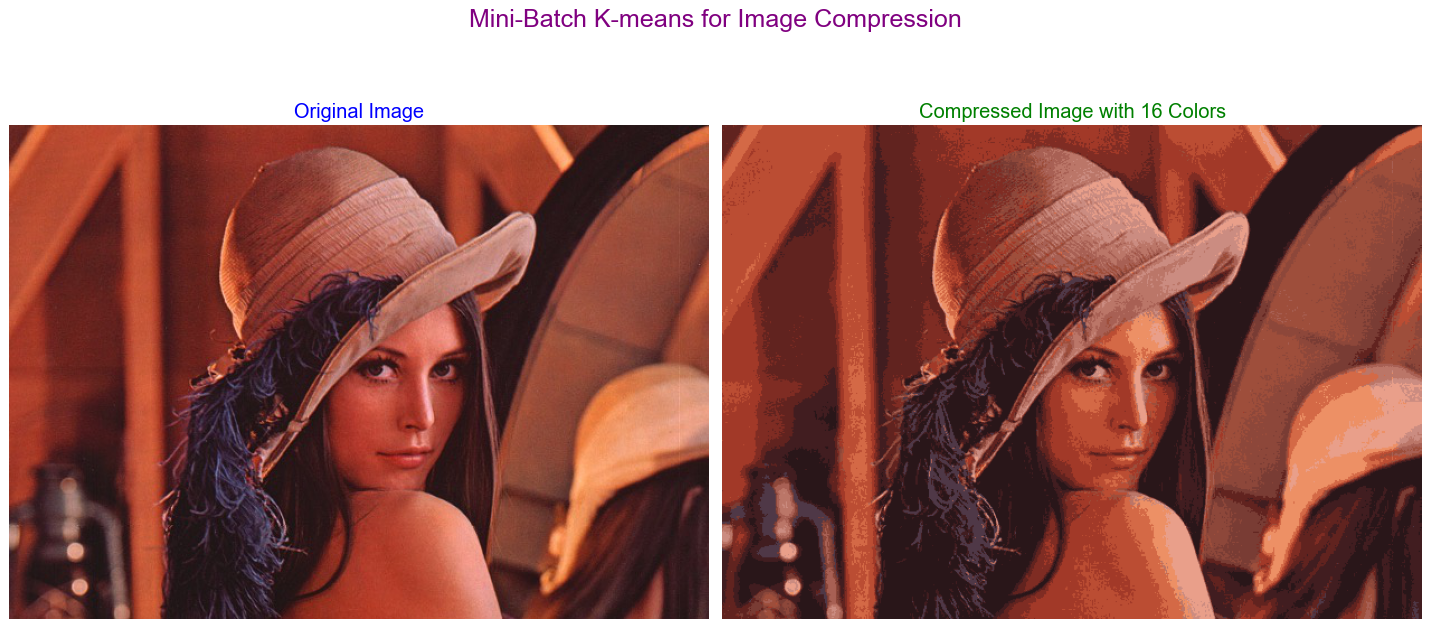

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils import shuffle
from PIL import Image

# 加载图像
image_path = DATA_DIR / 'lenna.jpg' 
image = Image.open(image_path)
image = image.convert("RGB")  # 确保图像是 RGB 格式
image = np.array(image)

# 获取图像形状
rows, cols, channels = image.shape

# 展平图像为 (N, 3) 的数组，每行是一个像素的 RGB 值
image_reshaped = image.reshape(-1, 3)

# 随机采样一部分像素用于训练
n_colors = 16  # 聚类的颜色数量
batch_size = 1024  # Mini-batch 的大小

# 使用 Mini-Batch K-means 进行颜色聚类
kmeans = MiniBatchKMeans(n_clusters=n_colors, batch_size=batch_size, random_state=42)
kmeans.fit(image_reshaped)

# 用聚类结果压缩图像
compressed_palette = kmeans.cluster_centers_.astype("uint8")  # 聚类中心作为新的颜色
labels = kmeans.predict(image_reshaped)  # 每个像素的标签
compressed_image = compressed_palette[labels].reshape(rows, cols, channels)

# 绘制原始图像和压缩图像
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# 显示原始图像
axs[0].imshow(image)
axs[0].set_title("Original Image", fontsize=16, color="blue")
axs[0].axis("off")

# 显示压缩后的图像
axs[1].imshow(compressed_image)
axs[1].set_title(f"Compressed Image with {n_colors} Colors", fontsize=16, color="green")
axs[1].axis("off")

# 添加一个炫酷的整体标题
plt.suptitle("Mini-Batch K-means for Image Compression", fontsize=20, color="purple")
plt.tight_layout()
plt.show()

1. **数据加载与预处理**：加载本地图片并转换为 $N \times 3$的 RGB 矩阵，准备进行聚类。
2. **Mini-Batch K-means 聚类**：

   - 使用 Mini-Batch K-means 对像素颜色进行聚类。
   - `n_clusters` 设置目标颜色数量。
   - `batch_size` 控制每次使用的像素数，适合处理大图像。
3. **压缩图像生成**：每个像素点的颜色用其对应的聚类中心替换，实现颜色压缩。
4. **可视化结果**：左图显示原始图像，右图显示压缩后的图像。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

运行代码后，大家会看到原始图像和压缩图像的对比。压缩后的图像色彩简化，保留了主要颜色特征。大家也可以通过调整 `n_colors` 和 `batch_size` 来探索不同的压缩程度。

## 优缺点和适用场景

**优点**：

1. **高效处理大规模数据**：Mini-Batch K-means 在每次迭代中仅使用一个小批量数据（mini-batch），显著减少了计算量，非常适合大规模数据集。内存使用率低，因为无需将整个数据集加载到内存。
2. **实时性**：可以逐步处理数据流（streaming data），适用于需要快速更新结果的场景。
3. **收敛速度快**：由于每次仅使用部分数据更新质心，算法可以快速迭代并得到较为满意的聚类结果。
4. **易于实现并行化**：小批量操作易于在分布式系统或 GPU 上并行处理。

**缺点**：

1. **准确性可能下降**：因为每次只使用一小部分数据更新质心，可能会导致最终结果的准确性略低于标准 K-means。对于较小的数据集，Mini-Batch K-means 的优势不明显，甚至可能表现更差。
2. **对初始质心敏感**：和普通 K-means 一样，初始质心的选择对最终结果有较大影响。
3. **难以处理复杂数据结构**：仅适用于基于欧几里得距离的聚类问题，对于非线性分布或高维稀疏数据效果较差。
4. **难以确定合适的 mini-batch 大小**：Mini-batch 大小的选择需要权衡计算效率与准确性，经验上通常选择 256 或 512，但并不总是适合所有数据集。

### 适用场景

1. 大规模数据场景：数据集规模超出内存容量，无法一次性加载整个数据集。需要快速近似结果的任务，如实时分析或快速原型设计。
2. 数据流处理（Streaming Data）：在需要处理动态更新的数据流时，Mini-Batch K-means 可以通过逐步优化质心实现实时聚类。
3. 在线学习（Online Learning）：动态用户行为建模。实时推荐系统。
4. 数据预处理：图像分割（快速将图像分成不同区域）。降维（通过聚类减少特征维度）。数据分桶（将连续数据离散化为不同簇）。